# 10강 연습문제

당신은 매일 아침 동네 빵집에서 식빵을 구입해 왔다.
이 식빵의 무게는 500g이라고 표시되어 있다. 하지만 당신은 자신이 구매하는 빵이 500g이 맞는
지 의구심이 들기 시작한다. 그래서 1개월간 식빵을 사운 뒤 매일 무게를 기록하였고 그 결과는
bread 데이터셋으로 저장하였다.
25일간 측정한 빵의 평균 무게는 480g이었다. 이 값을 가지고 식빵의 무게가 500g이 되지 않는
다며 베이커리를 찾아가 컴플레인을 해야 할까?

In [2]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
from math import sqrt
# 단일표본 T-Test를 위한 라이브러리
from scipy.stats import t, ttest_1samp, normaltest

In [4]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [5]:
origin = load_data('bread')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10/bread.xlsx
[desc] 매일 아침 동네 빵집에서 식빵을 구입해 무게를 기록한 데이터
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (25, 1)
열 개수: 1
행 개수: 25

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   무게      25 non-null     int64
dtypes: int64(1)
memory usage: 332.0 bytes
None


,무게
0,482
1,479
2,485
3,474
4,479


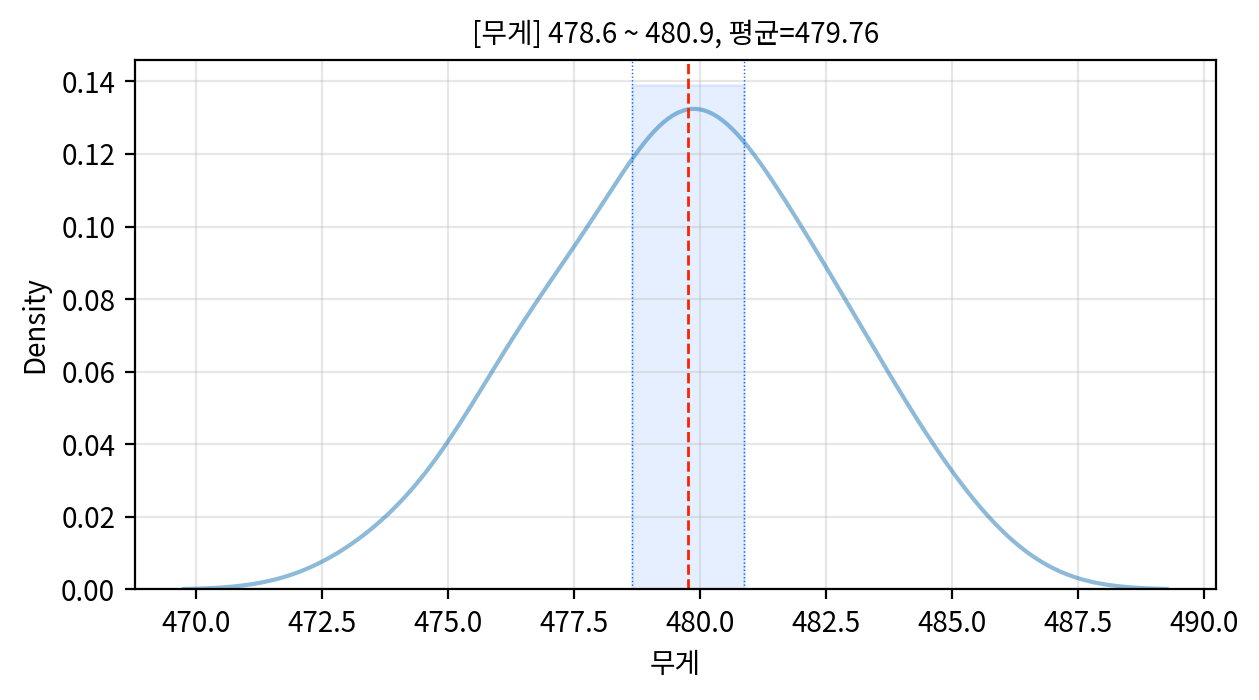

In [6]:
data = origin['무게'] # 확인할 데이터(컬럼단위)
max = data.max() # 최대값
clevel = 0.95 # 신뢰수준
dof = len(data) - 1 # 자유도
sp_mean = data.mean() # 표본평균
sp_std = data.std(ddof=1) # 표본표준편차
sp_std_error = sp_std / sqrt(len(data)) # 표본표준오차

# 신뢰구간
cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) KDE Plot 그리기
sb.kdeplot(data=data, fill=False, alpha=0.5)

# 신뢰구간 범위 그리기 (cmin ~ cmax)
ax.axvline(cmin, linestyle=':', color='#0066ff', linewidth=0.5)
ax.axvline(cmax, linestyle=':', color='#0066ff', linewidth=0.5)

# 현재 축 범위 가져오기
ymin, ymax = ax.get_ylim()
ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1, color='#0066ff88')
# 평균 표시
ax.axvline(sp_mean, linestyle='--', linewidth=1, color='#ff2200')

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시/숨김
ax.set_title(f"[{data.name}] {cmin:.1f} ~ {cmax:.1f}, 평균={sp_mean:0.2f}", fontsize=10)

# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

In [7]:
s, p = normaltest(origin['무게'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,p, p > 0.05)

'statistic: 0.083, p-value: 0.959, 정규성 충족 여부: True'

In [ ]:
s, p = ttest_1samp(origin['무게'], 500, alternative='less')
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -37.524, p-value: 0.000, 대립가설 채택'

해당 빵집의 신뢰구간은 478.6~480.9로써 빵의 평균 무게가 500이하가 확인이 된다
또한 T검정에 대한 해당 빵집의 무게 유의확률값은 0.000으로 통상적인 유의수준 0.05보다 작으므로 모집단의 평균인 500이라고 할 수 없다.(대립가설) 